# SVM y K-Means sobre Breast Cancer Wisconsin

**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC)  
**Fuente principal:** UCI Machine Learning Repository  
**Liga:** https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic  
**Referencia en Scikit-learn:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

El conjunto de datos contiene mediciones obtenidas a partir de imágenes digitalizadas de aspirados con aguja fina de masas mamarias. Cada **registro representa una muestra de tumor** y contiene **30 variables numéricas** que describen características de los núcleos celulares, como radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal. Para estas características se incluyen medidas de media, error estándar y valor *worst*.

La variable objetivo es **`diagnosis`**:
- `B`: benigno.
- `M`: maligno.

El campo **`id`** es únicamente un identificador de la muestra y no se utilizará como predictor.

**Pregunta supervisada:** ¿Es posible predecir si una muestra es maligna o benigna a partir de sus características numéricas mediante una máquina de soporte vectorial (SVM)?

**Pregunta no supervisada:** ¿Se forman grupos naturales de muestras con características similares si ignoramos temporalmente el diagnóstico y aplicamos K-Means?

## 1. Librerías

In [ ]:
import os
import zipfile
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)

## 2. Carga del dataset

In [ ]:
# Busca primero el ZIP en el entorno. Si no existe y estamos en Colab, solicita subirlo.
zip_candidates = list(Path('.').glob('breast+cancer+wisconsin+diagnostic*.zip'))

if zip_candidates:
    zip_name = str(zip_candidates[0])
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        zip_name = next(iter(uploaded))
    except ImportError:
        raise FileNotFoundError(
            "Coloca el archivo breast+cancer+wisconsin+diagnostic.zip en la misma carpeta del notebook."
        )

extract_dir = Path('wdbc_dataset')
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)

print('Archivo utilizado:', zip_name)
print('Contenido extraído:', sorted(os.listdir(extract_dir)))

Saving breast+cancer+wisconsin+diagnostic.zip to breast+cancer+wisconsin+diagnostic.zip
Archivo utilizado: breast+cancer+wisconsin+diagnostic.zip
Contenido extraído: ['wdbc.data', 'wdbc.names']


In [ ]:
# El archivo wdbc.data no incluye encabezados, por lo que se asignan manualmente.
base_features = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave_points', 'symmetry',
    'fractal_dimension'
]

columnas = ['id', 'diagnosis']
columnas += [f'{x}_mean' for x in base_features]
columnas += [f'{x}_se' for x in base_features]
columnas += [f'{x}_worst' for x in base_features]

df = pd.read_csv(extract_dir / 'wdbc.data', header=None, names=columnas)

print('Dimensiones del dataset:', df.shape)
df.head()

Dimensiones del dataset: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Revisión inicial de estructura y calidad

In [ ]:
print('Número de registros:', df.shape[0])
print('Número de variables:', df.shape[1])

print('\nVariables disponibles:')
print(df.columns.tolist())

print('\nTipos de datos:')
print(df.dtypes)

faltantes = df.isna().sum()
print('\nValores faltantes totales:', int(faltantes.sum()))
print('Columnas con faltantes:')
print(faltantes[faltantes > 0] if faltantes.sum() > 0 else 'Ninguna')

print('\nDuplicados:', int(df.duplicated().sum()))

print('\nDistribución de la variable objetivo:')
distribucion = pd.DataFrame({
    'Cantidad': df['diagnosis'].value_counts(),
    'Porcentaje': (df['diagnosis'].value_counts(normalize=True) * 100).round(2)
})
print(distribucion)

Número de registros: 569
Número de variables: 32

Variables disponibles:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Tipos de datos:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        flo

### Interpretación de la revisión inicial

El dataset contiene **569 registros y 32 columnas**. De estas columnas, `id` funciona únicamente como identificador, `diagnosis` corresponde a la variable objetivo y las otras **30 variables son características numéricas** que pueden utilizarse como predictoras.

No se encontraron valores faltantes ni registros duplicados, por lo que el conjunto presenta una calidad adecuada para realizar los modelos sin requerir una limpieza extensa.

También se observa que las clases no tienen exactamente la misma cantidad de registros, por lo que será importante conservar su proporción al dividir los datos en entrenamiento y prueba.

In [ ]:
# Limpieza mínima y justificada.
registros_iniciales = len(df)

# Se eliminan duplicados si existieran.
df = df.drop_duplicates().copy()

# Se eliminarían registros incompletos si existieran, porque SVM y K-Means
# necesitan valores numéricos válidos para este ejercicio.
df = df.dropna().copy()

print('Registros eliminados durante la limpieza:', registros_iniciales - len(df))
print('Dimensiones después de la limpieza:', df.shape)

Registros eliminados durante la limpieza: 0
Dimensiones después de la limpieza: (569, 32)


### Limpieza de datos

La limpieza aplicada fue mínima debido a que el dataset se encuentra prácticamente preparado para el análisis. Se verificaron y eliminarían duplicados o registros incompletos únicamente en caso de existir.

En este caso no fue necesario eliminar ningún registro, por lo que se conservaron las **569 observaciones originales**. El identificador `id` tampoco será utilizado como predictor, ya que representa únicamente un número de identificación y no una característica del tumor.

## 4. Preparación de variables

In [ ]:
# Se conservan únicamente variables numéricas como predictoras y se excluye el ID.
X = df.drop(columns=['id', 'diagnosis']).select_dtypes(include=np.number).copy()

# Para el modelado: B = 0 y M = 1.
y = df['diagnosis'].map({'B': 0, 'M': 1}).astype(int)

# Copia de las etiquetas reales para evaluación supervisada y comparación final.
y_real = y.copy()
diagnosis_real = df['diagnosis'].copy()

print('Número de predictoras numéricas:', X.shape[1])
print('Variable objetivo: 0 = benigno, 1 = maligno')
print('Todas las predictoras son numéricas:', X.shape[1] == 30)

Número de predictoras numéricas: 30
Variable objetivo: 0 = benigno, 1 = maligno
Todas las predictoras son numéricas: True


### Preparación y escalamiento de las variables

Se utilizan las **30 variables numéricas** como predictoras. La variable `diagnosis` se separa de `X` y se transforma a valores numéricos únicamente para facilitar la evaluación del clasificador:

- `0` = benigno
- `1` = maligno

También se conserva una copia de las etiquetas originales para comparar posteriormente los clusters obtenidos por K-Means, sin utilizarlas durante el entrenamiento del algoritmo no supervisado.

El escalamiento de las variables es especialmente importante porque algunas características, como el área, pueden tener valores mucho mayores que otras.

En **SVM**, las diferencias de escala pueden modificar las distancias y la posición de la frontera de decisión. En **K-Means**, las distancias determinan directamente la asignación de observaciones a los centroides. Por esta razón, una variable con valores numéricamente grandes podría dominar el resultado si los datos no fueran estandarizados.

## 5. División de entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)

print('\nProporción de clases en entrenamiento:')
print(y_train.value_counts(normalize=True).sort_index().round(3))

print('\nProporción de clases en prueba:')
print(y_test.value_counts(normalize=True).sort_index().round(3))

Entrenamiento: (455, 30)
Prueba: (114, 30)

Proporción de clases en entrenamiento:
diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64

Proporción de clases en prueba:
diagnosis
0    0.632
1    0.368
Name: proportion, dtype: float64


### División de entrenamiento y prueba

Se utiliza una partición de **80 % para entrenamiento y 20 % para prueba**, obteniendo 455 observaciones para entrenamiento y 114 para evaluación.

Se establece `random_state=42` para que la división sea reproducible y `stratify=y` para conservar aproximadamente la misma proporción de casos benignos y malignos en ambos subconjuntos.

Esta separación permite evaluar el modelo utilizando datos que no fueron utilizados durante su entrenamiento, proporcionando una estimación más realista de su capacidad para clasificar nuevas observaciones.

## 6. SVM: kernel lineal y kernel RBF

In [ ]:
# El escalamiento se integra dentro del Pipeline para que StandardScaler
# se ajuste únicamente con los datos de entrenamiento.
modelos = {
    'Modelo 1': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', C=1))
    ]),
    'Modelo 2': Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=1, gamma='scale'))
    ])
}

kernels = {'Modelo 1': 'Lineal', 'Modelo 2': 'RBF'}
resultados = []
predicciones = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    predicciones[nombre] = pred

    resultados.append({
        'Modelo SVM': nombre,
        'Kernel': kernels[nombre],
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1-score': f1_score(y_test, pred, zero_division=0)
    })

resultados_svm = pd.DataFrame(resultados)
resultados_svm.round(4)

,Modelo SVM,Kernel,Accuracy,Precision,Recall,F1-score
0,Modelo 1,Lineal,0.9649,1.0,0.9048,0.950
1,Modelo 2,RBF,0.9737,1.0,0.9286,0.963


### Comparación de los modelos SVM

Se evaluaron dos configuraciones de Support Vector Machine utilizando exactamente la misma partición de datos:

- **Modelo 1:** kernel lineal.
- **Modelo 2:** kernel RBF.

El modelo lineal obtuvo aproximadamente **96.49 % de accuracy** y un **F1-score de 0.9500**, mientras que el modelo RBF alcanzó aproximadamente **97.37 % de accuracy** y un **F1-score de 0.9630**.

Por lo tanto, el modelo con **kernel RBF presenta el mejor desempeño general**, aunque la diferencia entre ambos modelos es relativamente pequeña.

En este problema se considera al diagnóstico maligno (`1`) como la clase positiva. Por ello, `precision` mide qué proporción de los casos clasificados como malignos realmente lo eran, mientras que `recall` indica qué proporción de todos los tumores malignos existentes logró detectar el modelo.

El F1-score combina precision y recall, por lo que resulta útil para seleccionar un modelo que mantenga equilibrio entre ambos tipos de desempeño.

El problema es binario y se toma **maligno (`1`)** como clase positiva. Por ello, no es necesario utilizar un promedio `macro` o `weighted`, requisito que aplica principalmente cuando existen más de dos clases.


## 7. Matriz de confusión del mejor SVM

Mejor modelo según F1-score: Modelo 2 - RBF
Matriz de confusión:
[[72  0]
 [ 3 39]]

Verdaderos negativos (benignos correctos): 72
Falsos positivos (benignos clasificados como malignos): 0
Falsos negativos (malignos clasificados como benignos): 3
Verdaderos positivos (malignos correctos): 39


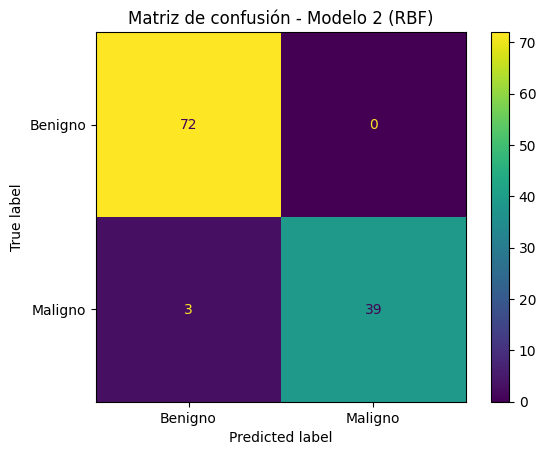

In [ ]:
# Se elige el mejor modelo por F1-score para equilibrar precision y recall.
mejor_fila = resultados_svm.loc[resultados_svm['F1-score'].idxmax()]
mejor_nombre = mejor_fila['Modelo SVM']
mejor_pred = predicciones[mejor_nombre]

cm = confusion_matrix(y_test, mejor_pred)
tn, fp, fn, tp = cm.ravel()

print('Mejor modelo según F1-score:', mejor_nombre, '-', kernels[mejor_nombre])
print('Matriz de confusión:')
print(cm)
print(f'\nVerdaderos negativos (benignos correctos): {tn}')
print(f'Falsos positivos (benignos clasificados como malignos): {fp}')
print(f'Falsos negativos (malignos clasificados como benignos): {fn}')
print(f'Verdaderos positivos (malignos correctos): {tp}')

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Benigno', 'Maligno']
).plot()
plt.title(f'Matriz de confusión - {mejor_nombre} ({kernels[mejor_nombre]})')
plt.show()

In [ ]:
recall_benigno = tn / (tn + fp)
recall_maligno = tp / (tp + fn)

print(f'Recall de benignos: {recall_benigno:.4f}')
print(f'Recall de malignos: {recall_maligno:.4f}')

if recall_benigno > recall_maligno:
    print('La clase benigna fue más fácil de distinguir en esta partición.')
elif recall_maligno > recall_benigno:
    print('La clase maligna fue más fácil de distinguir en esta partición.')
else:
    print('Ambas clases tuvieron la misma tasa de detección en esta partición.')

print('\nLa accuracy no basta por sí sola porque no muestra qué tipo de error ocurre.')
print('En este problema, un falso negativo es especialmente importante porque corresponde')
print('a una muestra maligna que el clasificador predijo como benigna.')

Recall de benignos: 1.0000
Recall de malignos: 0.9286
La clase benigna fue más fácil de distinguir en esta partición.

La accuracy no basta por sí sola porque no muestra qué tipo de error ocurre.
En este problema, un falso negativo es especialmente importante porque corresponde
a una muestra maligna que el clasificador predijo como benigna.


### Interpretación de la matriz de confusión

El modelo seleccionado fue el **SVM con kernel RBF**, debido a que obtuvo el mayor F1-score.

La matriz de confusión muestra:

- **72 verdaderos negativos:** casos benignos correctamente identificados.
- **39 verdaderos positivos:** casos malignos correctamente identificados.
- **0 falsos positivos:** ningún caso benigno fue clasificado incorrectamente como maligno.
- **3 falsos negativos:** tres casos malignos fueron clasificados incorrectamente como benignos.

La clase benigna fue ligeramente más fácil de identificar, alcanzando un recall de **1.00**, mientras que la clase maligna obtuvo aproximadamente **0.9286**.

La accuracy por sí sola no es suficiente para evaluar este problema porque no indica qué tipo de errores está realizando el modelo. En un contexto de diagnóstico, un **falso negativo es especialmente importante**, ya que significa que una muestra realmente maligna fue clasificada como benigna.

Por esta razón, además de accuracy deben analizarse métricas como precision, recall, F1-score y la matriz de confusión.

## 8. Modificación del hiperparámetro C

In [ ]:
comparacion_C = []

for C in [0.1, 1, 10]:
    modelo_c = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', C=C, gamma='scale'))
    ])

    modelo_c.fit(X_train, y_train)
    pred_c = modelo_c.predict(X_test)

    comparacion_C.append({
        'C': C,
        'Accuracy': accuracy_score(y_test, pred_c),
        'Precision': precision_score(y_test, pred_c, zero_division=0),
        'Recall': recall_score(y_test, pred_c, zero_division=0),
        'F1-score': f1_score(y_test, pred_c, zero_division=0)
    })

resultados_C = pd.DataFrame(comparacion_C)
resultados_C.round(4)

,C,Accuracy,Precision,Recall,F1-score
0,0.1,0.9474,1.0,0.8571,0.9231
1,1.0,0.9737,1.0,0.9286,0.9630
2,10.0,0.9737,1.0,0.9286,0.9630


In [ ]:
mejor_C = resultados_C.loc[resultados_C['F1-score'].idxmax(), 'C']
peor_C = resultados_C.loc[resultados_C['F1-score'].idxmin(), 'C']

print('Mejor C según F1-score:', mejor_C)
print('Menor F1-score observado con C =', peor_C)
print('\nCambiar C modifica cuánto penaliza SVM los errores de entrenamiento.')
print('Un C pequeño permite más errores y favorece un margen más amplio y regular.')
print('Un C grande penaliza más los errores y puede producir una frontera más ajustada.')
print('Si C es demasiado alto, aumenta el riesgo de sobreajuste.')
print('En el kernel RBF, gamma controla qué tan local es la influencia de cada observación;')
print('valores altos de gamma pueden generar fronteras más complejas y también sobreajuste.')

Mejor C según F1-score: 1.0
Menor F1-score observado con C = 0.1

Cambiar C modifica cuánto penaliza SVM los errores de entrenamiento.
Un C pequeño permite más errores y favorece un margen más amplio y regular.
Un C grande penaliza más los errores y puede producir una frontera más ajustada.
Si C es demasiado alto, aumenta el riesgo de sobreajuste.
En el kernel RBF, gamma controla qué tan local es la influencia de cada observación;
valores altos de gamma pueden generar fronteras más complejas y también sobreajuste.


### Efecto del hiperparámetro C

Se compararon los valores `C = 0.1`, `C = 1` y `C = 10` utilizando el mismo SVM con kernel RBF.

Con `C = 0.1` el desempeño disminuyó, especialmente el recall de los casos malignos. En cambio, `C = 1` obtuvo el mejor resultado y aumentar el parámetro hasta `C = 10` no produjo una mejora adicional en esta partición.

El parámetro **C controla cuánto penaliza SVM los errores de clasificación**. Un valor pequeño permite más errores durante el entrenamiento y favorece un margen más amplio y regular. Un valor elevado intenta ajustar mejor las observaciones de entrenamiento y puede producir una frontera más compleja.

Si `C` es demasiado grande, el modelo puede adaptarse excesivamente a los datos de entrenamiento y aumentar el riesgo de sobreajuste.

En el kernel RBF también existe el parámetro `gamma`, que determina el alcance de influencia de cada observación. Valores muy elevados de `gamma` pueden generar fronteras excesivamente complejas y también favorecer el sobreajuste.

## 9. K-Means sin utilizar la variable objetivo

In [ ]:
# Para K-Means se usan únicamente las 30 variables predictoras.
# diagnosis/y_real NO se utilizan para entrenar ni ajustar el clustering.
scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X)

resultados_k = []

for k in range(2, 7):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=20)
    clusters_temp = kmeans_temp.fit_predict(X_scaled)

    resultados_k.append({
        'k': k,
        'Inercia': kmeans_temp.inertia_,
        'Silhouette': silhouette_score(X_scaled, clusters_temp)
    })

resultados_k = pd.DataFrame(resultados_k)
resultados_k.round(4)

,k,Inercia,Silhouette
0,2,11595.4615,0.3450
1,3,10061.7978,0.3144
2,4,9257.3625,0.2803
3,5,8557.7275,0.1585
4,6,7970.2638,0.1604


## 10. Método del codo y silhouette score

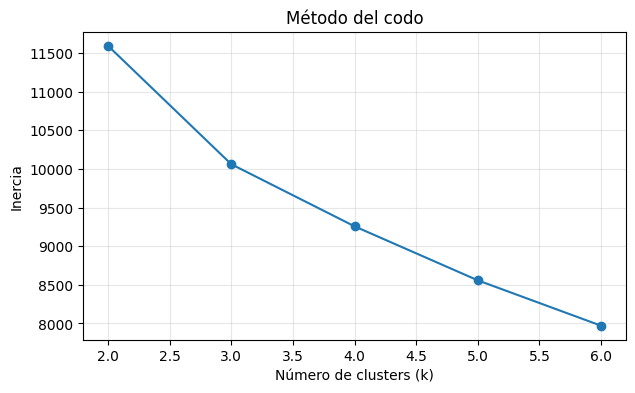

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(resultados_k['k'], resultados_k['Inercia'], marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(alpha=0.3)
plt.show()

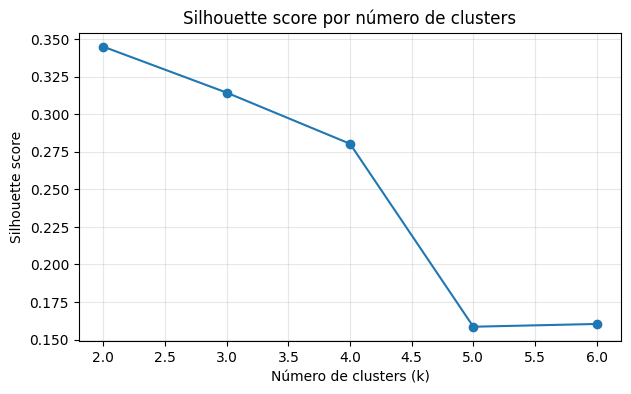

   k     Inercia  Silhouette
0  2  11595.4615      0.3450
1  3  10061.7978      0.3144
2  4   9257.3625      0.2803
3  5   8557.7275      0.1585
4  6   7970.2638      0.1604


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(resultados_k['k'], resultados_k['Silhouette'], marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score por número de clusters')
plt.grid(alpha=0.3)
plt.show()

print(resultados_k.round(4))

In [ ]:
# Selección cuantitativa: se toma el k con mayor silhouette score.
k_final = int(resultados_k.loc[resultados_k['Silhouette'].idxmax(), 'k'])
mejor_silhouette = resultados_k['Silhouette'].max()

print('k seleccionado:', k_final)
print(f'Mejor silhouette score: {mejor_silhouette:.4f}')

k seleccionado: 2
Mejor silhouette score: 0.3450


### Selección del número de clusters

Se analizaron valores de **k entre 2 y 6** utilizando dos criterios: la inercia mediante el método del codo y el silhouette score.

La inercia disminuye conforme aumenta el número de clusters, algo esperado porque existen más centroides disponibles para representar las observaciones. Sin embargo, aumentar `k` no necesariamente significa obtener grupos de mejor calidad.

El **silhouette score más alto fue aproximadamente 0.345 para k = 2**. Los valores obtenidos disminuyeron al utilizar 3, 4, 5 o 6 clusters.

Por esta razón se selecciona **k = 2**, ya que presenta la mejor separación y cohesión entre los valores evaluados y es consistente con la tendencia observada mediante el método del codo.

El método del codo es un criterio visual, mientras que el silhouette score aporta una medida cuantitativa de cohesión y separación. Por ello, se utiliza silhouette como criterio principal. Esta elección no implica que los dos clusters sean automáticamente equivalentes a benigno y maligno.


## 11. Modelo final K-Means y resumen de clusters

In [ ]:
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)
clusters = kmeans_final.fit_predict(X_scaled)

df_clusters = X.copy()
df_clusters['cluster'] = clusters

variables_principales = [
    'radius_mean',
    'texture_mean',
    'area_mean',
    'concavity_mean',
    'concave_points_mean',
    'radius_worst',
    'area_worst'
]

resumen_clusters = df_clusters.groupby('cluster')[variables_principales].mean().round(3)
resumen_clusters.insert(
    0,
    'Tamaño',
    df_clusters['cluster'].value_counts().sort_index()
)

resumen_clusters

,Tamaño,radius_mean,texture_mean,area_mean,concavity_mean,concave_points_mean,radius_worst,area_worst
cluster,,,,,,,,
0,189,17.557,21.359,993.67,0.180,0.094,21.292,1451.234
1,380,12.422,18.260,486.39,0.044,0.026,13.771,596.759


In [ ]:
# Interpretación basada en los perfiles promedio, sin usar diagnosis.
cluster_area_alta = resumen_clusters['area_mean'].idxmax()
cluster_area_baja = resumen_clusters['area_mean'].idxmin()

print(f'Cluster {cluster_area_alta}: concentra muestras con mayor tamaño promedio,')
print('mayor radio/área y mayor irregularidad asociada a concavidad y puntos cóncavos.')
print(f'Cluster {cluster_area_baja}: concentra muestras de menor tamaño promedio y')
print('menores niveles de concavidad y puntos cóncavos.')
print('\nEl patrón principal que separa los grupos combina tamaño e irregularidad morfológica,')
print('no una etiqueta clínica conocida, porque K-Means nunca recibió diagnosis.')

Cluster 0: concentra muestras con mayor tamaño promedio,
mayor radio/área y mayor irregularidad asociada a concavidad y puntos cóncavos.
Cluster 1: concentra muestras de menor tamaño promedio y
menores niveles de concavidad y puntos cóncavos.

El patrón principal que separa los grupos combina tamaño e irregularidad morfológica,
no una etiqueta clínica conocida, porque K-Means nunca recibió diagnosis.


### Interpretación de los clusters

K-Means identificó dos perfiles principales utilizando únicamente las características numéricas de las muestras.

El **cluster 0**, formado por aproximadamente 189 observaciones, presenta en promedio valores mayores de radio, área, concavidad, puntos cóncavos y tamaño máximo de las muestras. Esto representa un grupo caracterizado por estructuras de mayor tamaño y mayor irregularidad morfológica.

El **cluster 1**, con aproximadamente 380 observaciones, presenta valores promedio menores en estas características, formando un grupo de muestras generalmente más pequeñas y con menor grado de irregularidad.

Por lo tanto, los patrones que parecen separar los clusters están relacionados principalmente con el **tamaño y la irregularidad de las muestras**.

Esta interpretación se obtiene sin utilizar el diagnóstico real. En este punto todavía no puede afirmarse que un cluster represente casos benignos o malignos; únicamente puede decirse que K-Means encontró dos perfiles geométricamente distintos.

La interpretación es preliminar: un cluster describe similitud entre observaciones y no debe tratarse por sí mismo como un diagnóstico médico.


## 12. PCA para visualizar los clusters

Varianza explicada por PC1 y PC2: [0.4427 0.1897]
Varianza explicada total: 0.6324


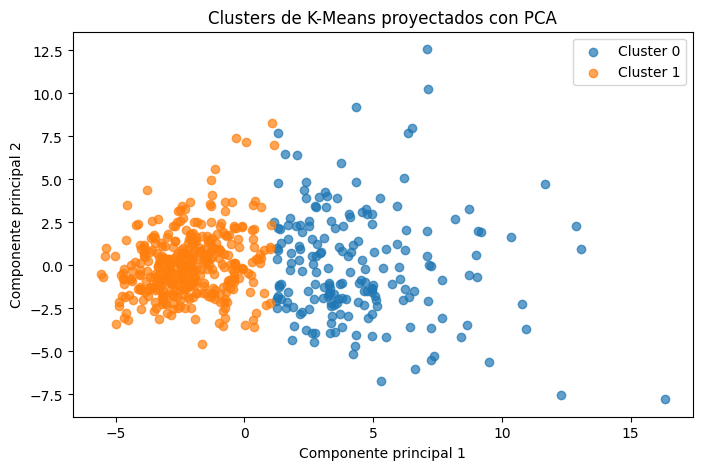

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Varianza explicada por PC1 y PC2:', pca.explained_variance_ratio_.round(4))
print('Varianza explicada total:', round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(8, 5))
for cluster_id in sorted(np.unique(clusters)):
    mask = clusters == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        alpha=0.7,
        label=f'Cluster {cluster_id}'
    )

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Clusters de K-Means proyectados con PCA')
plt.legend()
plt.show()

### Interpretación de PCA

Debido a que el dataset contiene 30 variables predictoras, no es posible representar directamente toda su estructura en una gráfica bidimensional. Por esta razón se utiliza PCA para proyectar las observaciones en dos componentes principales.

El primer componente explica aproximadamente **44.27 %** de la variabilidad y el segundo alrededor de **18.97 %**. En conjunto, ambos representan aproximadamente **63.24 % de la variación total** de los datos escalados.

La gráfica permite observar visualmente la separación obtenida por K-Means. Sin embargo, debe considerarse que la representación pierde parte de la información original, ya que únicamente se muestran dos componentes de un espacio originalmente formado por 30 variables.

## 13. PCA con las clases reales para comparación visual

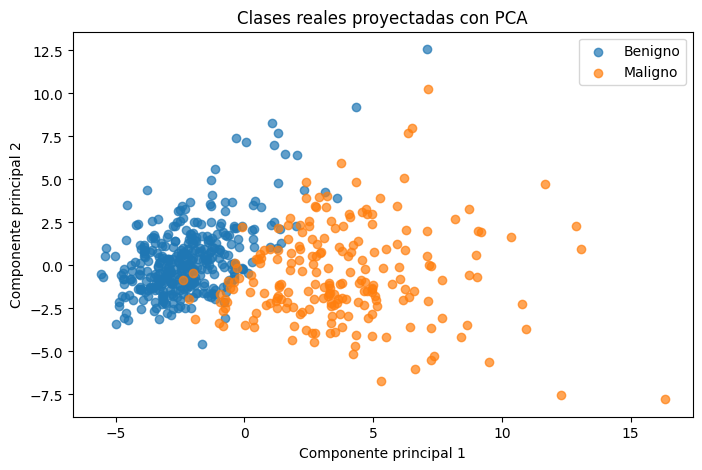

In [ ]:
plt.figure(figsize=(8, 5))

for valor, etiqueta in [(0, 'Benigno'), (1, 'Maligno')]:
    mask = y_real.to_numpy() == valor
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        alpha=0.7,
        label=etiqueta
    )

plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Clases reales proyectadas con PCA')
plt.legend()
plt.show()

### Comparación visual con las clases reales

Esta segunda representación utiliza las etiquetas de diagnóstico únicamente para facilitar la comparación visual con los clusters obtenidos anteriormente.

Las etiquetas reales **no fueron utilizadas para entrenar K-Means, seleccionar el número de clusters ni calcular sus centroides**.

Visualmente puede observarse una separación considerable entre muestras benignas y malignas, aunque también existen regiones en las que ambas clases presentan características similares.

Las etiquetas reales se utilizan únicamente después del clustering; no participaron en el escalamiento usado para K-Means, la selección de `k`, el entrenamiento ni la asignación de clusters.


## 14. Comparación de clusters con las clases conocidas

In [ ]:
comparacion = pd.crosstab(
    pd.Series(clusters, name='Cluster'),
    pd.Series(diagnosis_real.to_numpy(), name='Diagnóstico')
)

comparacion_porcentaje = pd.crosstab(
    pd.Series(clusters, name='Cluster'),
    pd.Series(diagnosis_real.to_numpy(), name='Diagnóstico'),
    normalize='index'
).mul(100).round(2)

print('Conteos por cluster y diagnóstico real:')
print(comparacion)

print('\nPorcentaje dentro de cada cluster:')
print(comparacion_porcentaje)

Conteos por cluster y diagnóstico real:
Diagnóstico    B    M
Cluster              
0             14  175
1            343   37

Porcentaje dentro de cada cluster:
Diagnóstico      B      M
Cluster                  
0             7.41  92.59
1            90.26   9.74


In [ ]:
for cluster_id in comparacion.index:
    clase_mayoritaria = comparacion.loc[cluster_id].idxmax()
    porcentaje = comparacion_porcentaje.loc[cluster_id, clase_mayoritaria]
    nombre = 'benigno' if clase_mayoritaria == 'B' else 'maligno'
    print(
        f'Cluster {cluster_id}: predominan casos {nombre}s '
        f'({porcentaje:.2f}% del cluster), pero existe mezcla de clases.'
    )

print('\nLa correspondencia es parcial, no exacta. K-Means minimiza distancias geométricas')
print('entre observaciones y centroides; no intenta reproducir una variable objetivo conocida.')

Cluster 0: predominan casos malignos (92.59% del cluster), pero existe mezcla de clases.
Cluster 1: predominan casos benignos (90.26% del cluster), pero existe mezcla de clases.

La correspondencia es parcial, no exacta. K-Means minimiza distancias geométricas
entre observaciones y centroides; no intenta reproducir una variable objetivo conocida.


### Comparación entre clusters y clases conocidas

Existe una correspondencia importante, aunque no perfecta, entre los grupos descubiertos por K-Means y los diagnósticos reales.

El **cluster 0 contiene aproximadamente 92.59 % de casos malignos**, mientras que el **cluster 1 contiene aproximadamente 90.26 % de casos benignos**. Esto indica que las características geométricas utilizadas por K-Means capturan una estructura relacionada con el diagnóstico.

Sin embargo, ambos clusters contienen una mezcla de casos benignos y malignos, por lo que **cluster y clase no son conceptos equivalentes**.

No debe esperarse que K-Means reproduzca exactamente las etiquetas originales porque el algoritmo desconoce el diagnóstico. Su objetivo consiste únicamente en minimizar las distancias entre observaciones y centroides, agrupando muestras según similitud geométrica.

En cambio, SVM utiliza directamente las etiquetas conocidas durante su entrenamiento y busca construir una frontera que permita diferenciar específicamente entre casos benignos y malignos.

## 15. Conclusión



Los dos enfoques utilizados permiten analizar el mismo conjunto de datos desde perspectivas diferentes.

El modelo **SVM representa aprendizaje supervisado**, ya que utiliza ejemplos con diagnósticos conocidos para aprender a distinguir entre tumores benignos y malignos. El kernel RBF obtuvo el mejor desempeño, alcanzando aproximadamente **97.37 % de accuracy y un F1-score de 0.9630**, por lo que resultó el enfoque más sencillo de evaluar e interpretar respecto al objetivo de clasificación.

La matriz de confusión permitió observar que el modelo cometió únicamente tres falsos negativos en el conjunto de prueba. Esto demuestra también por qué resulta necesario analizar precision, recall y F1-score además de la accuracy.

Por otra parte, **K-Means representa aprendizaje no supervisado**. El algoritmo no recibió información sobre los diagnósticos y agrupó las observaciones únicamente de acuerdo con su similitud. El análisis mediante el método del codo y silhouette score indicó que **k = 2** era la alternativa más adecuada entre los valores evaluados.

Los clusters encontrados mostraron diferencias principalmente relacionadas con el tamaño y la irregularidad morfológica de las muestras. Al compararlos posteriormente con las clases reales se encontró una correspondencia considerable: un cluster concentró principalmente muestras malignas y el otro principalmente muestras benignas. Sin embargo, la correspondencia no fue perfecta porque K-Means no intenta predecir una etiqueta conocida.

PCA permitió representar visualmente esta estructura reduciendo las 30 características originales a dos componentes, aunque esta proyección conserva únicamente una parte de la variabilidad total.

En conclusión, **SVM sería apropiado cuando existen etiquetas conocidas y el objetivo consiste en predecir la clase de nuevas observaciones**, mientras que **K-Means sería útil cuando no existen etiquetas y se desea explorar patrones, segmentos o estructuras naturales presentes en los datos**. Ambos métodos aportan información diferente y su elección depende del problema que se desea resolver.